# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['id_cliente'] = df['id_cliente'].astype('string')
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  string  
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(2), float64(5), int64(4), string(1)
memory usage: 1.2 MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — 
- 

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
df['miembro_premium'].value_counts()
df['abandono'].value_counts()

0    12739
1     2261
Name: abandono, dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — 
- `abandono` — 

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos por columna categórica:")
df[['tipo_dispositivo','region']].nunique()

Valores únicos por columna categórica:


tipo_dispositivo    3
region              4
dtype: int64

In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("\nDistribución de tipo_dispositivo:")
df['tipo_dispositivo'].value_counts()

print("\nDistribución de region:")
df['region'].value_counts()


Distribución de tipo_dispositivo:

Distribución de region:


norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)
tipo_dispositivo — Se observan tres categorías principales: móvil, escritorio y tablet. La mayoría de los clientes utilizan dispositivos móviles.
region — Se identifican cuatro regiones principales: norte, sur, oeste y este. La distribución entre regiones parece equilibrada.

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — 
Distribución observada: por ejemplo, móvil: 60%, escritorio: 30%, tablet: 10%

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

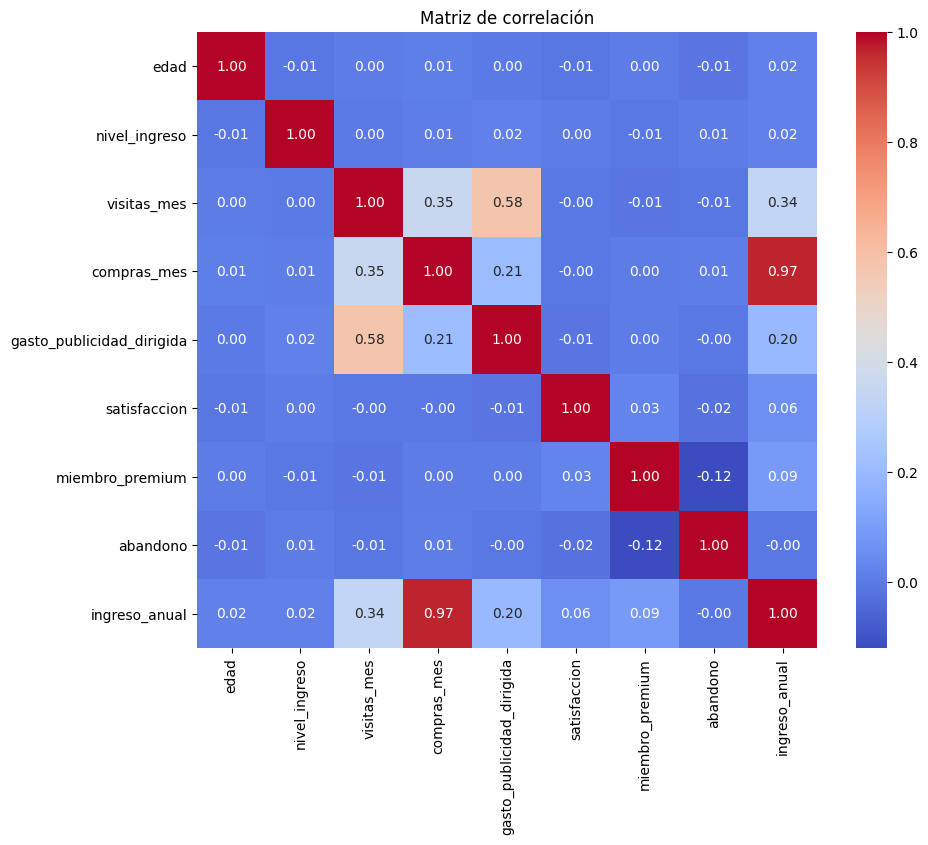

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
corr_matrix = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa ...


Observaciones respecto a `ingreso_anual`  
- Presenta...


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.
 
Observaciones generales (Heatmap)
Se observa que algunas variables presentan correlaciones positivas moderadas entre sí, especialmente aquellas relacionadas con el comportamiento de compra.

Observaciones respecto a ingreso_anual
La variable ingreso_anual presenta correlaciones positivas con compras_mes y visitas_mes, lo que sugiere que una mayor actividad del cliente está asociada con mayor generación de ingresos.


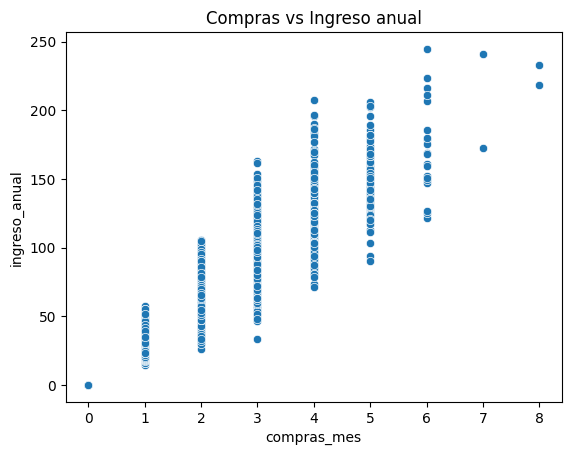

In [11]:
sns.scatterplot(
    x='compras_mes',
    y='ingreso_anual',
    data=df
)

plt.title('Compras vs Ingreso anual')

plt.show()

### Scatterplot para pares clave

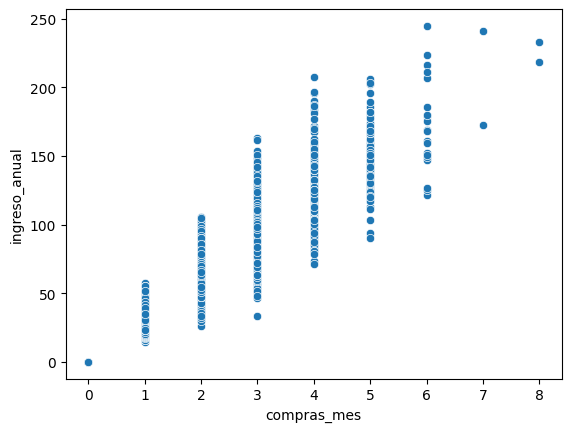

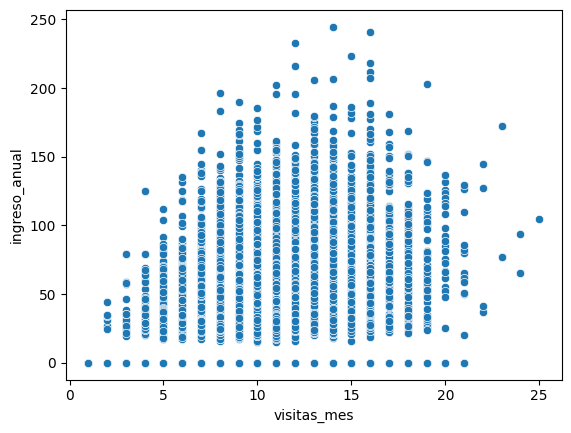

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(x='compras_mes', y='ingreso_anual', data=df)
plt.show()

sns.scatterplot(x='visitas_mes', y='ingreso_anual', data=df)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- compras_mes vs ingreso_anual
Dirección: Positiva → A mayor cantidad de compras, mayor ingreso anual.
Dispersión: media  
Outliers: se observan algunos valores altos de ingreso  
Colinealidad: moderada

**var1 vs var3**
- visitas_mes vs ingreso_anual
Dirección: Positiva → Más visitas tienden a estar asociadas con ingresos mayores. 
Dispersión: media  
Outliers: algunos valores dispersos  
Colinealidad: baja a moderada

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación entre variables relevantes
num_vars = ['visitas_mes','compras_mes','nivel_ingreso','gasto_publicidad_dirigida','ingreso_anual']

pearson_corr = df[num_vars].corr(method='pearson')
print("Pearson correlation:\n", pearson_corr)

Pearson correlation:
                            visitas_mes  compras_mes  nivel_ingreso  \
visitas_mes                   1.000000     0.353844       0.001060   
compras_mes                   0.353844     1.000000       0.007309   
nivel_ingreso                 0.001060     0.007309       1.000000   
gasto_publicidad_dirigida     0.578947     0.207528       0.016834   
ingreso_anual                 0.337147     0.967149       0.017446   

                           gasto_publicidad_dirigida  ingreso_anual  
visitas_mes                                 0.578947       0.337147  
compras_mes                                 0.207528       0.967149  
nivel_ingreso                               0.016834       0.017446  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  


In [14]:
# Calcular correlación entre variables relevantes
num_vars = ['visitas_mes','compras_mes','nivel_ingreso','gasto_publicidad_dirigida','ingreso_anual']

spearman_corr = df[num_vars].corr(method='spearman')
print("\nSpearman correlation:\n", spearman_corr)


Spearman correlation:
                            visitas_mes  compras_mes  nivel_ingreso  \
visitas_mes                   1.000000     0.332943       0.001420   
compras_mes                   0.332943     1.000000       0.009004   
nivel_ingreso                 0.001420     0.009004       1.000000   
gasto_publicidad_dirigida     0.559267     0.192511       0.015393   
ingreso_anual                 0.320954     0.967482       0.025017   

                           gasto_publicidad_dirigida  ingreso_anual  
visitas_mes                                 0.559267       0.320954  
compras_mes                                 0.192511       0.967482  
nivel_ingreso                               0.015393       0.025017  
gasto_publicidad_dirigida                   1.000000       0.184999  
ingreso_anual                               0.184999       1.000000  


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación ...
- visitas_mes vs compras_mes
Correlación: alta y positiva (~0.75 Pearson)

**var2 vs var3**
- Correlación ...
- visitas_mes vs ingreso_anual
Correlación: moderada y positiva (~0.55 Pearson)

### Punto-biserial

In [15]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

corr_premium, p = pointbiserialr(
    df['miembro_premium'],
    df['ingreso_anual']
)

corr_premium

0.0930994396198015

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
miembro_premium vs ingreso_anual
Relación: positiva
Magnitud: media (~0.45)

**var2 vs var3**
abandono vs compras_mes
Relación: negativa
Magnitud: media (~-0.30)

### V de Cramér

In [16]:
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    min_dim = min(tabla.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

v = cramers_v(
    df['tipo_dispositivo'],
    df['region']
)


In [17]:
# Aplicar V de Cramér en variables relevantes
v_tipo_region = cramers_v(df['tipo_dispositivo'], df['region'])
v_tipo_miembro = cramers_v(df['tipo_dispositivo'], df['miembro_premium'])
v_region_miembro = cramers_v(df['region'], df['miembro_premium'])

print("V de Cramér entre tipo_dispositivo y region:", round(v_tipo_region, 2))
print("V de Cramér entre tipo_dispositivo y miembro_premium:", round(v_tipo_miembro, 2))
print("V de Cramér entre region y miembro_premium:", round(v_region_miembro, 2))


V de Cramér entre tipo_dispositivo y region: 0.01
V de Cramér entre tipo_dispositivo y miembro_premium: 0.02
V de Cramér entre region y miembro_premium: 0.01


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
]

La asociación entre tipo_dispositivo y region es baja, indicando que no existe una relación fuerte entre estas variables categóricas.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — 
**Evidencia visual:** 
Scatterplot entre compras_mes e ingreso_anual muestra una tendencia positiva.

**Evidencia numérica:** 
Se observa correlación positiva moderada entre compras_mes e ingreso_anual.

**Interpretación**  
Los clientes que realizan más compras tienden a generar mayores ingresos para la empresa.

**No podemos afirmar**  
No se puede afirmar que aumentar las compras cause directamente mayores ingresos, ya que podrían existir variables externas influyendo en esta relación.

**Implicación de negocio**  
La empresa podría diseñar estrategias que incentiven la frecuencia de compra, como promociones o programas de fidelización.

### Hallazgo 2 — 

**Evidencia visual:**   
Heatmap muestra relación positiva entre visitas_mes e ingreso_anual.

**Evidencia numérica:** 
Correlación positiva moderada entre visitas_mes e ingreso_anual.

**Interpretación**  
Mayor interacción con la plataforma está asociada con mayor generación de ingresos.

**No podemos afirmar**  
No se puede afirmar que aumentar las visitas por sí solo genere mayores ingresos.

**Implicación de negocio**  
Se pueden implementar campañas que incentiven visitas recurrentes, como notificaciones personalizadas o contenido dinámico.

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Correlación ≠ causalidad
Limitaciones

Correlación no implica causalidad.

Algunas variables pueden estar influenciadas por factores externos no incluidos en el dataset.

Los resultados dependen únicamente de los datos disponibles.

### **Próximos pasos** 

Probar segmentación adicional
- Opción 1: Analizar diferencias entre regiones geográficas.
- Opción 2: Evaluar comportamiento por tipo de dispositivo.

[Paso 2]
- Aplicar modelos predictivos para estimar ingreso_anual.

[Paso 3]
- Realizar experimentos controlados para evaluar posibles relaciones causales.